## **Тьюториал "Параллельные алгоритмы поиска аномалий во временных рядах" на всероссийской научной конференции с международным участием [«Параллельные вычислительные технологии (ПаВТ) 2026»](https://xn--80ae1bo.xn--p1ai/2026/)**

### **Часть 1. Введение в задачу поиска аномалий**

##### **Задание 1.** Подготовка GPU-среды выполнения

Перед началом прохождения практической части тьюториала выполните подключение Google Диск для сохранения материалов тьюториала и полученных результатов, а также клонируйте [GitHub-репозиторий с материалами](https://github.com/KraevaYA/pct-tutorial-2026). Репозиторий будет склонирован непосредственно на Google Диск, что обеспечит постоянное хранение всех материалов. При последующих запусках достаточно будет перейти в эту директорию. Далее установите все необходимые зависимости.

In [ ]:
# INSERT YOUR CODE

Выполните настройку Numba для работы с CUDA и проверьте доступность GPU. Для этого выполните следующие команды:
*    `config.CUDA_ENABLE_PYNVJITLINK = 1`: включает поддержку Just-In-Time компиляции для GPU, необходимую для выполнения ядер CUDA в Numba.
*   `!nvidia-smi`: выводит информацию об установленном графическом процессоре, версии драйверов и CUDA.
*   `!nvcc --version`: отображает версию компилятора CUDA, что подтверждает корректность установки инструментов разработки.

In [ ]:
from numba import config
config.CUDA_ENABLE_PYNVJITLINK = 1

In [ ]:
!nvidia-smi

In [ ]:
!nvcc --version

Импортируйте необходимые библиотеки и модули.

In [ ]:
import numpy as np
import pandas as pd

from anomaly_detection.plots import *
from anomaly_detection.algorithms.serial import STOMP
from anomaly_detection.metrics import get_metrics

В данном тьюториале для выполнения частей 1 и 2 в качестве данных будет использоваться временной ряд [NYC_Taxi](https://doi.org/10.1109/ICMLA.2015.141), который показывает среднечасовое количество пассажировов такси в течение 75 дней осенью 2014 года.

Исходные данные хранятся в csv-файле *nyc_taxi.csv*, расположенном в директории *./datasets*. В каждой строке файла содержится следующая информация, разделенная `;` :
*   временная метка в формате %d.%m.%y %H:%M, где %d — день месяца, %m — месяц, %y — две последние цифры года, а %H:%M — часы в 24-часовом формате и минуты;
*   количество пассажиров, которые воспользовались такси в течение 30 минут, отсчитываемых c соответствующей временной метки;
*   метка, принимающая значение 0 или 1. Если метка равна 1, то это показывает о начале некоторого нетипичного события, приводящего к появлению аномалии в данных.

Согласно разметке, в данных имеется две аномалии.

##### **Задание 2.** Загрузка и визуализация ряда NYC Taxi

Загрузите временной ряд NYC_Taxi из файла *nyc_taxi.csv*, расположенного в директории *./datasets*. Для этого воспользуйтесь функцией `read_csv()` из библиотеки *pandas*. Настройте считывание файла таким образом, чтобы первый столбец использовался в качестве индекса, а первая строка – в качестве названия столбцов. После успешного считывания с помощью функции `to_datetime()` из *pandas* преобразуйте столбец с временными метками в объекты datetime, указав необходимый формат %d.%m.%y %H:%M.

In [ ]:
ts_path = './datasets/nyc_taxi.csv'

# INSERT YOUR CODEs

Для просмотра временного ряда NYC_Taxi постройте двумерный график. Для этого вызовите функцию `plot_ts()` из модуля *plots.py*, передав ей в качестве аргументов значения временного ряда `ts['value']`, название графика (например, 'Time series NYC_Taxi'), названия вертикальной и горизонтальной осей (например, 'Time' и 'Passenger number' соответственно).

In [ ]:
# INSERT YOUR CODE

Одним из вариантов решения задачи поиска диссонансов во временной ряде является вычисление матричного профиля ряда.

**Матричным профилем ряда $T$** для длины подпоследовательности $m$ называется ряд $MP$, $i$-м элементом которого является расстояние между $i$-й подпоследовательностью ряда, имеющей длину $m$, и ее ближайшим соседом той же длины $m$:
\begin{equation}
    MP = \{\text{Dist}(T_{i,\,m}, T_{j,\,m})\}_{i=1}^{n-m+1},
    \\
    {где} \quad T_{j,\,m}=\arg \min_{1\leqslant q\leqslant n-m+1} \text{Dist}(T_{i,\,m}, T_{q,\,m}), \quad |i-q| > m.
\end{equation}

Матричный профиль дает аналитику понимание свойств подпоследовательностей временного ряда через степень сходства этих подпоследовательностей со своими ближайшими соседями. Так, например, *локальные максимумы* матричного ряда соответствуют *аномалиям* (диссонансам) ряда.

##### **Задание 3.** Поиск top-$k$ диссонансов

Для поиска top-$k$ диссонансов на основе матричного профиля выполните следующие действия:
*   Создайте экземпляр класса `STOMP`, передав в конструктор длину диссонанса `m` и количество диссонансов `top_k`, которые необходимо найти.
*   Вызовите метод `predict()` у созданного экземпляра, передав ему значения временного ряда `ts['value'].values`.

В качестве значений задайте `m = 96` и `top_k = 5`.


In [ ]:
# INSERT YOUR CODE

В результате выполнения метода `predict()` будет возвращен словарь, содержащий следующее:
*   `m` – длины найденных диссонансов;
*   `indices` — индексы диссонансов (порядковые номера подпоследовательностей-диссонансов во временном ряде);
*   `distances` — расстояния от диссонансов до их ближайших соседей;
*   `nn_indices` — индексы ближайших соседей для каждого диссонанса;
*   `mp` — матричный профиль ряда.

Чтобы убедиться в этом, выполните вывод полученных результатов.

In [ ]:
# INSERT YOUR CODE

Выполните визуализацию найденных top-$k$ диссонансов с помощью функции `plot_discords()` из модуля *plots.py*, передав временной ряд `ts`, результат выполнения алгоритма поиска диссонансов, полученный на предыдущем шаге, `discords` и флаг `is_detailed =  True`, включающий детальный режим визуализации. При установке этого аргумента на графике будут дополнительно отображены <font color='green'>верно найденные диссонансы</font> (True Positive, TP), <font color='red'>ложные срабатывания</font> (False Positive, FP), <font color='gray'>пропущенные аномалии</font> (False Negative, FN).

In [ ]:
# INSERT YOUR CODE

**Выводы:**

На верхнем графике представлен исходный временной ряд с отмеченными диссонансами, найденными алгоритмом. В среднем графике показан матричный профиль, содержащий расстояния от каждой подпоследовательности ряда до их ближайших соседей. Нижний график отображает истинную разметку, которая указывает на наличие двух аномалий в моменты времени 01.11.2014 19:00 и 27.11.2014 15:30. Эти аномалии объясняются двумя событиями в США:
1.   переходом с летнего на зимнее время, осуществляемым ежегодно в первое воскресенье ноября и выпавшим в 2014 году на 2 ноября;
2.   Днем благодарения, празднование которого ежегодно проводится в четвертый четверг ноября, и выпавшим в 2014 году на 27 ноября.

Можно видеть, что алгоритм находит все истинные диссонансы, однако среди предсказанных диссонансов есть и три ложно-положительных, появившиеся в моменты времени 12.10.2014 01:30, 28.11.2014 02:30 и 11.12.2014 22:00. Несмотря на то, что данные диссонансы отмечены как FP, обнаружение их алгоритмом не является безосновательным:
*   диссонанс (12.10.2014 01:30) можно связать с праздником Днем Колумба, отмечаемым ежегодно 12 октября в честь прибытия Х. Колумба в Америку 12 октября 1492;
*   диссонанс (28.11.2014 02:30) можно связать с «Черной пятницей», днем массовых распродаж.

Диссонанс 11.12.2014 22:00 остается необъясненным — возможно, ажиотаж перед рождественским праздником?

Таким образом, можно сделать вывод о том, что алгоритм позволяет находить диссонансы, которые зрительно нельзя обнаружить.

### **Часть 2. Поиск диссонансов фиксированной длины**

#### Последовательный алгоритм DRAG (Discord Range Aware Gathering)

Однако сложность вычисления матричного профиля высока и составляет $O(n^2)$, где $n$ — длина ряда, что в случае больших временных рядов приводит к низкому быстродействию. Существуют более эффективные алгоритмы поиска диссонансов во временных рядах. К таким алгоритмам относят алгоритм [DRAG](https://doi.org/10.1109/ICDM.2007.61). DRAG основан на понятии диапазонного диссонанса. Под **диапазонным диссонансом** понимается подпоследовательность ряда длины $m$, ближайший сосед которой находится на расстоянии не менее наперед заданного порога $r$. Алгоритм DRAG включает две фазы: отбор и очистка кандидатов, на которых выполняется поиск потенциальных диссонансов и отбрасывание ложноположительных экземпляров соответственно.


##### **Задание 4.** Алгоритм DRAG (CPU)

Выполните поиск диапазонных диссонансов во временном ряде NYC_Taxi с помощью алгоритма DRAG. Для этого создайте экземпляр класса `DRAG`, передав в конструктор следующие параметры:
*   `m = 96` — длина диссонанса;
*   `r = 1.85` — пороговое расстояние до ближайшего соседа.

Затем вызовите метод `predict()` у созданного экземпляра, передав ему значения временного ряда `ts['value'].values.astype('float64')`.

In [ ]:
from anomaly_detection.algorithms.serial import DRAG
from anomaly_detection.experiments import Experiment

In [ ]:
# INSERT YOUR CODE

В результате метод `predict()` вернет найденные диапазонные диссонансы. Далее выполните вывод полученных результатов.

In [ ]:
# INSERT YOUR CODE

Постройте графики, визуализирующие найденные алгоритмом DRAG диссонансы, с помощью функции `plot_discords()` из модуля *plots.py*.

In [ ]:
# INSERT YOUR CODE

##### **Задание 5.** Исследование влияния порога

Проведите эксперимент по исследованию влияния порога $r$ на точность алгоритма DRAG, а также на количество найденных кандидатов и диссонансов на фазах отбора и очистки.

Для оценки точности используйте стандартные метрики качества, определяемые следующим образом:
\begin{equation}
    Precision = \frac{TP}{TP+FP}; \quad Recall=\frac{TP}{TP+FN}; \quad F1=2\cdot\frac{Precision\cdot Recall}{Precision+Recall}, \;\; где
\end{equation}

$Precision$ – доля истинных диссонансов среди всех предсказанных алгоритмом диссонансов.

$Recall$ – доля верно предсказанных диссонансов среди всех истинных диссонансов.

$F1$-мера – гармоническое среднее между $Precision$ и $Recall$, сбалансированно учитывающее как ложные, так и пропущенные аномалии.

Для проведение эксперимента создайте экземпляр класса  `Experiment`, передав ему следующие параметры:
*   `cpu_alg = DRAG` — используемый алгоритм;
*   `fixed_params = {'m': 96}` — фиксированная длина диссонанса;
*   `arying_params = {'r': np.arange(0.5, 5, 0.5)}` — порог $r$ от 0.5 до 5 с шагом 0.5;
*   `metrics = ['phase_stats', 'accuracy']` — сбор статистики по фазам и метрик качества.

Запустите эксперимент методом `run()`, передав значения временного ряда и аннотацию истинных аномалий. Визуализируйте результаты с помощью метода `plot()`.

In [ ]:
exp1 = Experiment(cpu_alg=DRAG,
                  fixed_params={'m': 96},
                  varying_params={'r': np.arange(0.5, 5, 0.5)},
                  metrics=['phase_stats', 'accuracy'])
results_exp1 = exp1.run(ts['value'].values.astype('float64'),
                        annotation=ts['label'].values)
exp1.plot()

**Выводы:**

На первом графике представлена зависимость количества кандидатов (фаза отбора) и диссонансов (фаза очистки) от значения порога $r$. Видно, что при увеличении значения порога $r$, количество найденных кандидатов и диссонансов на фазах алгоритма DRAG уменьшается.

На втором графике отображены метрики качества $Precision$, $Recall$ и $F1$ в зависимости от $r$. Можно заметить, что при слишком маленьких значениях порога $r$ (при $r=0.5$, $r=1.0$, $r=1.5$) алгоритм DRAG находит как истинные диссонансы (соответствующие указанным выше событиям в США), так и  ложноположительные. Этот факт доказывается низкими показателями $Precision$ по сравнению с большими значениями $r$. Таким образом, чем меньше $r$, тем больше ложных диссонансов и тем меньше становится метрика $Precision$ (приближается к нулю).

При слишком больших значениях порога $r$ (при $r=4.5$) алгоритм DRAG не находит все истинные диссонансы в исходном ряде. Наблюдается падение метрики $Recall$ в два раза относительно значений при меньших $r$.

Тем самым, результат алгоритма DRAG критически зависит от подбора порога $r$. Неудачно подобранный порог может привести к избыточному количеству ложноположительных диссонансов, либо к пропуску истинных аномалий.

Выполните визуализацию результатов работы алгоритма DRAG для трех различных значений порога $r$: маленького, оптимального и большого (например,
`r=1`, `r=3` и `r=4.5`). Для каждого значения создайте экземпляр класса `DRAG` с соответствующим параметром `r` (при фиксированном `m=96`), выполните поиск диссонансов методом `predict()`, затем постройте график с помощью функции `plot_discords()`из модуля `plots.py`.

In [ ]:
# INSERT YOUR CODE

#### Параллельный алгоритм PD3 (Parallel DRAG-based Discord Discovery)

Параллельный алгоритм [PD3](https://doi.org/10.1134/S1054661823020062) для GPU основан на последовательном алгоритме [DRAG](https://doi.org/10.1109/ICDM.2007.61) Янкова и др. В отличие от исходного алгоритма, PD3 использует квадрат нормализованного евклидова расстояния в качестве метрики для ускорения вычислений. Кроме того, в алгоритм PD3 добавлена ​​фаза предобработки, заключающаяся в параллельном вычислении средних значений и стандартных отклонений всех подпоследовательностей временного ряда. Результаты затем используются на фазах отбора и очистки кандидатов для вычисления расстояний между подпоследовательностями временного ряда. Каждая из этих фаз алгоритма распараллеливается отдельно на основе концепции параллелизма по данным и использования векторных структур данных.

##### **Задание 6.** Алгоритм PD3 (GPU)

Выполните поиск диапазонных диссонансов во временном ряде NYC_Taxi с помощью алгоритма PD3. Для этого создайте экземпляр класса `PD3` из модуля *pd3.py*, передав в конструктор параметры `m = 96` и `r = 1.85` (аналогично алгоритму DRAG). Затем вызовите метод `predict()`, передав ему значения временного ряда `ts['value'].values.astype('float64')`.

In [ ]:
from anomaly_detection.algorithms.parallel import PD3

In [ ]:
# INSERT YOUR CODE

Далее выведите полученные результаты на экран и выполните визуализацию найденных с помощью PD3 диссонансов с помощью функции `plot_discords()`.

In [ ]:
# INSERT YOUR CODE

##### **Задание 7.** Сравнение быстродействия DRAG и PD3

Проведите вторую серию экспериментов по сравнению быстродействия последовательного алгоритма DRAG и параллельного алгоритма PD3. Для этого создайте экземпляр класса `Experiment`, передав ему:
*   `cpu_alg = DRAG`— последовательный алгоритм;
*   `gpu_alg = PD3` — параллельный алгоритм;
*   `fixed_params = {'m': 96}` — фиксированная длина диссонанса;
*   `varying_params = {'r': np.arange(0.5, 5, 0.5)}` — порог $r$ от 0.5 до 5 с шагом 0.5;
*   `metrics = ['time', 'speedup', 'phase_stats']` — собираемые метрики (время выполнения, ускорение, статистика по фазам).

Запустите эксперимент методом `run()`, передав значения временного ряда, и визуализируйте результаты с помощью метода `plot()`.

In [ ]:
exp2 = Experiment(cpu_alg=DRAG, gpu_alg=PD3,
                  fixed_params={'m': 96},
                  varying_params={'r': np.arange(0.5, 5, 0.5)},
                  metrics=['time', 'speedup', 'phase_stats'])
results_exp2 = exp2.run(ts['value'].values.astype('float64'))
exp2.plot()

**Выводы:**

Можно видеть, что параллельный алгоритм PD3 опережает последовательную версию DRAG как минимум на один порядок. При этом при увеличении параметра $r$ время выполнения обоих алгоритмов уменьшается. Это можно объяснить тем, что при увеличении порога отбрасывается больше кандидатов, что, в свою очередь, приводит к уменьшению времени, затрачиваемому на фазу очистки, и выполняется, в целом, меньше операций для вычисления расстояний между подпоследовательностями ряда.

### **Часть 3. Поиск диссонансов произвольной длины**

Несмотря на то, что алгоритмы DRAG и PD3 позволяют находить диапазонные диссонансы, они имеют два главных недостатка. Во-первых, необходимо вручную подбирать значение порога $r$. Во-вторых, необходимо задавать точную длину искомых диссонансов. На практике это может доставить трудности даже эксперту
в предметной области.

Следовательно, возникает потребность в алгоритмах, способных выполнять поиск диссонансов для всех длин из заданного диапазона с возможностью адаптивного подбора порога. Для решения этой задачи были разработаны алгоритм MERLIN и его параллельная версия PALMAD, которые устраняют указанные ограничения.

#### Последовательный алгоритм MERLIN

  Идея последовательного алгоритма [MERLIN](https://doi.org/10.1109/ICDM50108.2020.00147) заключается в многократном вызове алгоритма DRAG и адаптивном подборе параметра $r$ для каждой длины диссонанса $m$ из заданного диапазона $minL...maxL$. Подбор порога $r$ выполняется следующим образом:
1.   для $m = minL$ значение порога устанавливается как $r=2\sqrt{minL}$, поскольку это максимально возможное расстояние между любой парой подпоследовательностей длины $minL$;
2.   для $m \in [minL+1; minL+5)$ порог равен $r = 0.99 \cdot nnDist_{m-1}$, где $nnDist_{m-1}$ – расстояние от диссонанса, полученного на предыдущем шаге, до его ближайшего соседа за вычетом небольшой величины в 1%;
2.   для $m \in [minL+5; maxL]$ порог равен $r = \mu - 2\sigma$, где $\mu$ и $\sigma$ вычисляются на основе расстояний от диссонансов до их ближайших соседей пяти предыдущих длин как:
\begin{equation}
\mu \leftarrow \mathrm{Mean}(\{ nnDist_k\}^{m - 5}_{k=m - 1}); \quad
 \sigma \leftarrow \mathrm{StdDev}(\{ nnDist_k\}^{m - 5}_{k=m - 1}).
\end{equation}


Для выполнения части 3 тьюториала в качестве данных будет использоваться временной ряд PolyTER, который содержит показания беспроводного датчика температуры, снимавшиеся в течение 2018 года в одной из лекционных аудиторий кампуса Южно-Уральского государственного университета (ЮУрГУ) с периодичностью один раз в час. Свое название ряд получил от SCADA-системы PolyTER, установленной в ЮУрГУ. Эта система управляет теплоснабжением зданий университетского кампуса на основе анализа показаний проводных и беспроводных датчиков, установленных в помещениях ЮУрГУ.


Исходные данные хранятся в csv-файле *PolyTER_sensor_data_346.csv*, расположенном в директории *./datasets*. В каждой строке файла содержится следующая информация, разделенная ';' :
*  временная метка в формате `%Y-%m-%d %H:%M:S%`, где `%Y` – год, `%m` – месяц, `%d` – день месяца, а `%H:%M:%S` – часы в 24-часовом формате, минуты и секунды;
*  температура воздуха в аудитории.

Разметка в данных отсутствует.

In [ ]:
from anomaly_detection.algorithms.serial import MERLIN
from anomaly_detection.utils import select_topk_interest_discords, read_json_file

##### **Задание 8.** Загрузка и визуализация ряда PolyTER

Загрузите временной ряд PolyTER из файла *./datasets/PolyTER_sensor_data_346.csv*. Для этого воспользуйтесь функцией `read_csv()` из библиотеки *pandas*. Настройте считывание файла таким образом, чтобы первый столбец использовался в качестве индекса, а первая строка – в качестве названия столбцов. После успешного считывания с помощью функции `to_datetime()` из *pandas* преобразуйте столбец с временными метками в объекты datetime, указав необходимый формат `%Y-%m-%d %H:%M:%S`. Далее выполните визуализацию ряда с помощью функции `plot_ts()` (как в задании 2 из части 1).

In [ ]:
ts_path = './datasets/PolyTER_sensor_data_346.csv'

# INSERT YOUR CODE

##### **Задание 9.** Алгоритм MERLIN (CPU)

Выполните поиск top-$k$ диссонансов во временном ряде PolyTER с помощью алгоритма MERLIN. Для этого создайте экземпляр класса `MERLIN`, передав в конструктор левую границу диапазона длин диссонансов $minL$, правую границу $maxL$ и количество диссонансов $topK$. Затем вызовите метод `predict()`, передав ему значения временного ряда.

Значения параметров алгоритма следующие:
*  `minL = 60` — левая граница диапазона длин (2.5 суток);
*  `maxL = 144` — правая граница диапазона длин (6 суток);
*  `topK = 10` — количество искомых диссонансов каждой длины.

**Важно!** Алгоритм MERLIN выполняется на временном ряде PolyTER значительно дольше допустимого времени работы тьюториала, поэтому запуск алгоритма на занятии не предусмотрен. Вместо этого используйте заранее сохраненные результаты, импортировав их из JSON-файла *./results/MERLIN_PolyTER_m_60_144_topK_10.json* с помощью функции `read_json_file()`, передав путь до этого файла.

In [ ]:
# INSERT YOUR CODE
#minL = 60
#maxL = 144
#topK = 10

#merlin = MERLIN(minL, maxL, topK=topK)
#merlin_discords = merlin.predict(ts['value'].values.astype('float64'))

merlin_discords = read_json_file('./results/MERLIN_PolyTER_m_60_144_topK_10.json')

Далее выполните поиск top-$k$ интересных диссонансов, незавимо от их длин. Будем считать, что диссонансы наиболее интересны и полезны те, которые обладают наибольшей степенью аномальности среди всех найденных на предыдущем шаге. Степень аномальности диссонанса вычисляется путем нормирования расстояния от диссонанса до его ближайшего соседа с помощью множителя $\frac{1}{2m}$:
\begin{equation}
score(m, i) = \frac{T_{i, m}.nnDist}{2m}, \quad score(m,i) \in [0,1].
\end{equation}

Для получения top-$k$ интересных диссонансов вызовите функцию `select_topk_interest_discords()` из модуля *utils.py* и передайте в качестве аргументов полученные алгоритмом MERLIN результаты `merlin_discords` и количество интересных диссонансов `topK_interest = 10`.

In [ ]:
# INSERT YOUR CODE

Выполните визуализацию найденных top-$k$ интересных диссонансов с помощью функции `plot_discords()` из *plots.py*, для которой установите флаг `is_detailed = False`, отключающий детальный режим визуализации (из-за отсутствия аннотации аномалий).


In [ ]:
# INSERT YOUR CODE

**Вывод:**

На основе визуализации top-10 диссонансов, найденных алгоритмом MERLIN во временном ряде PolyTER, можно дать следующую содержательную интерпретацию каждому из них.

| Категория | Диссонансы | Описание |
|-----------|:------------:|:-----------:|
| **Неисправность датчика** | top‑1 (31 августа - 4 сентябрь), <br> top‑2 (20-26 октября), <br> top‑6 (30 июня – 6 июля) | Датчик выдает одинаковые показания <br>в течение соответствующего периода времени. |
| **Проветривание (открытые окна)** | top‑3 (1-7 декабря),  <br> top‑5 (14-20 марта),  <br> top‑9 (10-16 сентября),  <br> top‑10 (4-10 февраля) | Резкие отклонения температуры, <br> вызванные естественной вентиляцией аудитории. |
| **Выходные дни** | top‑4 (14-20 ноября),  <br> top‑7 (15-20 декабря),  <br> top‑8 (7-13 апреля) | Отсутствие занятий. |

Примеры диссонансов из каждой категории:
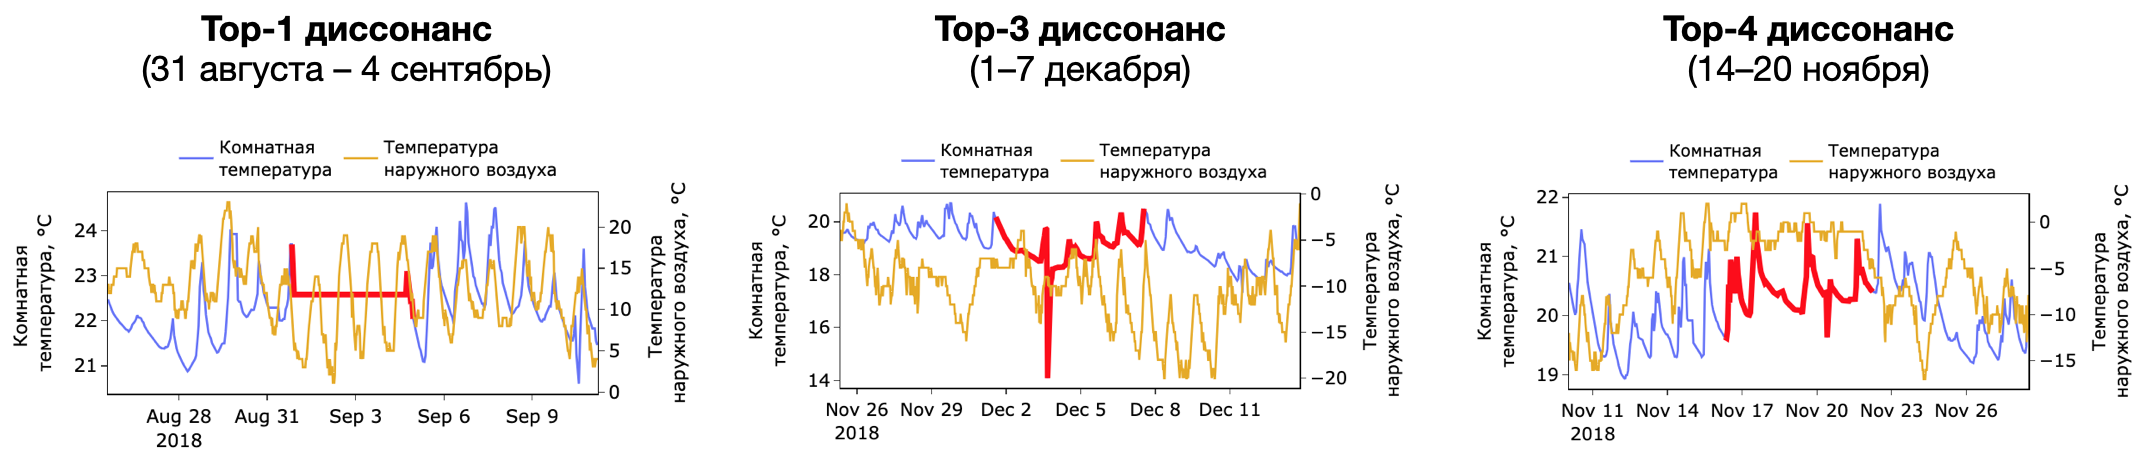

Таким образом, большинство диссонансов имеют физически обоснованную интерпретацию, что подтверждает эффективность алгоритма MERLIN для поиска аномалий во временных рядах.

Также визуализируйте тепловую карту диссонансов в помощью функции `plot_heatmap()` из модуля *plots.py*. Данная функция принимает временной ряд `ts` и диссонансы, полученные MERLIN. Тепловая карта представляет собой одноцветное изображение (матрицу) с размерами $(maxL - minL + 1) \times (n - minL)$, в котором интенсивность пикселя $(m, i)$ отражает оценку аномальности диссонанса $T_{i, m}$.

In [ ]:
# INSERT YOUR CODE

#### Параллельный алгоритм PALMAD (Parallel Arbitrary Length MERLIN-based Anomaly Discovery)

Параллельный алгоритм [PALMAD](https://doi.org/10.3390/math11143193) для GPU основан на последовательном алгоритме [MERLIN](https://doi.org/10.1109/ICDM50108.2020.00147), разработанном Накамурой и др.
Алгоритм PALMAD в целом повторяет вычислительную схему оригинального последовательного алгоритма MERLIN на графическом процессоре. PALMAD многократно вызывает алгоритм PD3, являющийся параллельной версией последовательного алгоритма DRAG для графического процессора. Отличительными особенностями алгоритма PALMAD являются использование выведенных рекуррентных формул для сокращения объема вычислений и разработка векторных структур данных для эффективной параллельной обработки данных.



##### **Задание 10.** Алгоритм PALMAD (GPU)

Выполните поиск диссонансов всевозможных длин из заданного диапазона с помощью алгоритма PALMAD на графическом процессоре. Для этого создайте экземпляр класса `PALMAD`, передав в конструктор параметры `minL = 60`, `maxL = 144` и `topK = 10` (аналогично алгоритму MERLIN). Затем вызовите метод `predict()`, передав ему значения временного ряда `ts['value'].values.astype('float64')`. Далее выполните поиск top-10 интересных диссонансов с помощью функции `select_topk_interest_discords()` и отобразите результаты на графике, воспользовавшись функцией `plot_discords()`.

In [ ]:
from anomaly_detection.algorithms.parallel import PALMAD

In [ ]:
# INSERT YOUR CODE

##### **Задание 11.** Сравнение быстродействия MERLIN и PALMAD

Проведите третью серию вычислительных экспериментов по сравнению быстродействия алгоритмов MERLIN и PALMAD при различных значениях параметра top-$k$. Для этого создайте экземпляр класса `Experiment`, передав ему:
*  `cpu_alg = MERLIN` – последовательный алгоритм;
*  `gpu_alg = PALMAD` – параллельный алгоритм;
*  `fixed_params = {'minL': 60, 'maxL': 144}` — фиксированные границы диапазона длин $minL$ и $maxL$;
*  `varying_params = {'topK': np.arange(1, 6)}` — варьируемый параметр top-$k$ от 1 до 5;
*  `metrics = ['time', 'speedup', 'phase_stats']` – собираемые метрики (время выполнения, ускорение, статистика по фазам.

Запустите эксперимент методом `run()`, передав значения временного ряда, и визуализируйте результаты с помощью метода `plot()`.

**Важно!** Выполнение данного эксперимента на временном ряде PolyTER требует значительного времени, поэтому запуск эксперимента на занятии производиться не будет. В соответствии с этим загрузите сохраненные ранее результаты эксперимента из файла *./results/MERLIN_vs_PALMAD_PolyTER_topK.csv* с помощью метода `load()` и визуализируйте их методом `plot()`.

In [ ]:
#minL = 60
#maxL = 144
#topK_list = np.arange(1, 6)

#exp3 = Experiment(cpu_alg=MERLIN, gpu_alg=PALMAD,
#                  fixed_params={'minL': minL, 'maxL': maxL},
#                  varying_params={'topK': topK_list},
#                  metrics=['time', 'speedup', 'phase_stats']
#                  )
#results_exp3 = exp3.run(ts['value'].values.astype('float64'))
#exp3.plot()

exp3 = Experiment()
results_exp3 = exp3.load('./results/MERLIN_vs_PALMAD_PolyTER_topK.csv')
exp3.plot()

**Вывод:** Можно видеть, что алгоритм PALMAD существенно превосходит алгоритм MERLIN в несколько раз.  